# Chapter 03 — PDF, OCR and Layout

*Where we are:* the **other** parsing path. Not every patent arrives as clean XML; many exist
only as **PDF**, which is a *presentation* format, not a semantic one.

```
[ PDF → text/words/boxes → OCR ]→ document model (+ bounding-box anchors)
```

**Why PDF is hard.** A PDF describes *where ink goes on a page*, not *what the document means*.
Text may live in a text layer (born-digital) or only as pixels (scanned). Reading order,
columns, and coordinates must be recovered. We work on a **genuine born-digital patent PDF**.

In [1]:
# === Chapter 03 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = True
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 03 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 03 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 7. PDF text extraction — text, words, coordinates

`PyMuPDF` gives us the text layer plus **word-level bounding boxes** `(x0, y0, x1, y1)` in PDF
points. Those coordinates are what let a future citation *highlight* the exact source region.

In [2]:
from patentrag import parsing as P
import pandas as pd
ext = bs.ensure("pdf_extractions")
path = ext["path"]
print("genuine patent PDF:", ext["doc_id"], "|", ext["page_count"], "pages |", ext["n_words_page0"], "words on page 0")
print("\ntext layer (page 0, head):")
print(ext["page0_text"][:220])

genuine patent PDF: US10083169B1 | 12 pages | 797 words on page 0

text layer (page 0, head):
TOMTOM DU IN UNA IMANI 
US010083169B1 
( 12 ) United States Patent 
Ghosh et al . 
( 10 ) Patent No 
. : 
US 10 , 083 , 169 B1 
( 45 ) Date of Patent : 
Sep . 25 , 2018 
( 54 ) TOPIC - BASED SEQUENCE MODELING 
NEURAL NET


In [3]:
words = P.pdf_words(path, 0)
wdf = pd.DataFrame(words, columns=["text", "x0", "y0", "x1", "y1"]).round(1)
wdf.head(10)

,text,x0,y0,x1,y1
0,TOMTOM,296.2,-0.9,351.1,54.3
1,DU,369.8,-0.9,390.5,54.3
2,IN,396.0,-0.9,410.9,54.3
3,UNA,414.7,-0.9,428.4,54.3
4,IMANI,435.4,-0.9,509.5,54.3
5,US010083169B1,381.6,34.9,452.2,53.7
6,(,78.2,62.6,83.5,93.2
7,12,82.6,62.6,89.3,93.2
8,),90.0,62.6,95.3,93.2
9,United,97.7,62.6,148.3,93.2


## 10. Bounding boxes → `SourceAnchor`

Each word box becomes a `SourceAnchor` with a `BoundingBox`, wiring page coordinates into the
same provenance type the XML path uses. Below we draw a few word boxes on the rasterized page.

In [4]:
from patentrag.parsing import word_anchor
anchor = word_anchor(ext["doc_id"], 0, words[5])
print("word:", repr(words[5][0]), "-> anchor:", anchor.model_dump(exclude_none=True))

word: 'US010083169B1' -> anchor: {'document_id': 'US10083169B1', 'page': 0, 'bbox': {'page': 0, 'x0': 381.6000061035156, 'y0': 34.90013885498047, 'x1': 452.1599426269531, 'y1': 53.74219512939453}}


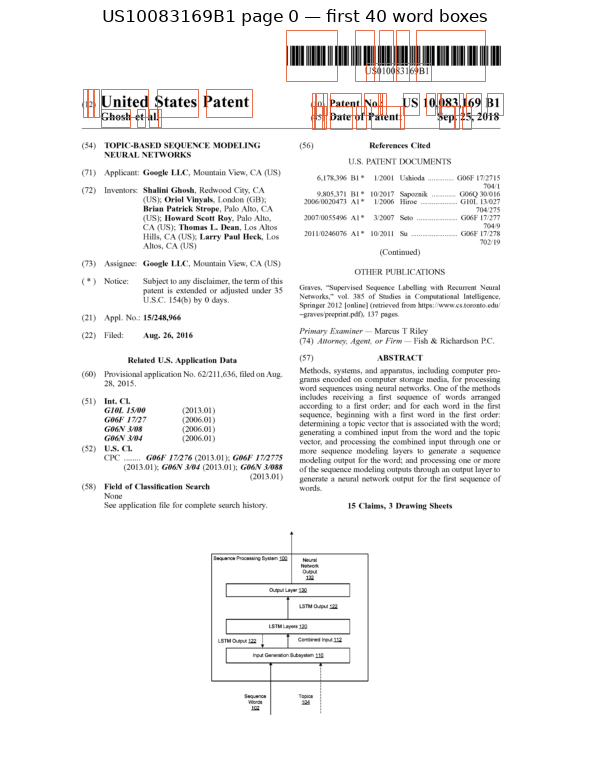

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
img = P.rasterize_page(path, 0, dpi=150)
scale = 150 / 72.0  # PDF points -> pixels
fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img)
for (t, x0, y0, x1, y1) in words[:40]:
    ax.add_patch(Rectangle((x0*scale, y0*scale), (x1-x0)*scale, (y1-y0)*scale,
                            fill=False, edgecolor="#E4572E", linewidth=0.6))
ax.set_title(f"{ext['doc_id']} page 0 — first 40 word boxes"); ax.axis("off")
plt.tight_layout(); plt.show()

## 8. OCR — born-digital text layer vs rasterize→OCR

A **scanned** patent has no text layer, so you must rasterize and run OCR. OCR introduces
**noise, confidence, and reading-order** problems. We simulate the scanned path by rasterizing
our born-digital page and OCR-ing it, then compare against the ground-truth text layer.

In [6]:
print("tesseract available:", P.ocr_available())
ocr = P.ocr_image(img)
tl = ext["page0_text"]
cer = P.char_error_rate(tl, ocr["text"])
print(f"text-layer chars : {len(tl)}")
print(f"OCR chars        : {len(ocr['text'])}   words: {len(ocr['words'])}   mean confidence: {ocr['mean_conf']:.1f}")
print(f"character error rate (text-layer vs OCR): {cer:.3f}")
print("\nOCR output (head):")
print(ocr["text"][:200])

tesseract available: True


text-layer chars : 3311
OCR chars        : 2730   words: 435   mean confidence: 83.6
character error rate (text-layer vs OCR): 0.544

OCR output (head):
United States Patent

US010083169B1

(12) (10) Patent US 10,083,169 B1
Ghosh et al. (45) Date of Patent: Sep. 25, 2018
(54) TOPIC-BASED SEQUENCE MODELING (56) References Cited
NEURAL NETWORKS
U.S. PAT


The CER is **not** ~0 even though this page *has* a perfect text layer — because a patent's
**two-column layout** makes OCR's linear reading order diverge from the logical order, and the
header/barcode region adds noise. That is the core lesson: **OCR output ≠ the semantic document**.
Confidence scores flag the low-quality regions.

In [7]:
# Show the lowest-confidence OCR words — where you would NOT trust the transcription.
low = sorted([w for w in ocr["words"] if w["text"].strip()], key=lambda w: w["conf"])[:8]
pd.DataFrame([{"text": w["text"], "confidence": w["conf"]} for w in low])

,text,confidence
0,“,0.0
1,Siok,0.0
2,7049,0.0
3,‘7o2N19,0.0
4,-,0.0
5,;,0.0
6,.......,0.0
7,oun,0.0


## 9. Layout analysis (lightweight)

Full layout models (Docling, LayoutParser, LayoutLM-family, PP-Structure, Surya) recover reading
order, tables and regions — powerful but heavy. A **lightweight** structural signal costs almost
nothing: the histogram of word x-positions reveals the **column structure** directly.

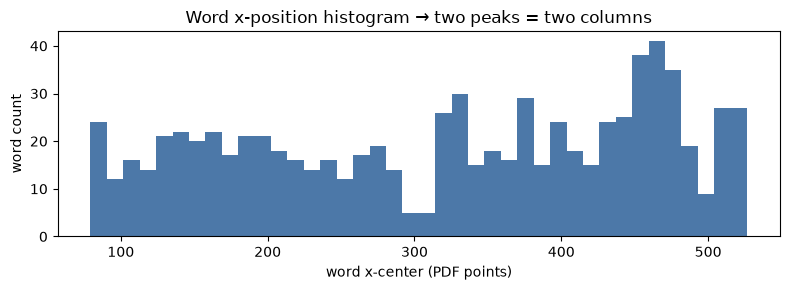

words left of median x: 398 | right: 399 — consistent with a two-column patent page


In [8]:
import numpy as np
xs = np.array([ (x0+x1)/2 for _, x0, y0, x1, y1 in words ])
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(xs, bins=40, color="#4C78A8")
page_mid = np.median([x1 for _,_,_,x1,_ in words])
ax.set_xlabel("word x-center (PDF points)"); ax.set_ylabel("word count")
ax.set_title("Word x-position histogram → two peaks = two columns")
plt.tight_layout(); plt.show()
# crude column split by the page midline
left = (xs < np.median(xs)).sum(); right = (xs >= np.median(xs)).sum()
print(f"words left of median x: {left} | right: {right} — consistent with a two-column patent page")

**Production implications.** Prefer the born-digital text layer when present (fast, exact);
fall back to OCR for scans, and **carry confidence downstream** so low-quality spans can be
de-weighted or re-OCR'd. Keep every word's bounding box — it is the anchor a citation highlights.
Layout models improve reading order for complex pages at real compute cost; choose per corpus.

## Chapter invariants

In [9]:
assert ext["available"] and ext["n_words_page0"] > 50
assert anchor.bbox is not None and anchor.bbox.page == 0
assert P.ocr_available(), "tesseract must be available (installed locally / apt-get on Colab)"
assert ocr["words"] and ocr["mean_conf"] > 0
assert 0.0 <= cer <= 2.0
print("All Chapter 03 invariants hold. pdf_extractions artifact ready.")

All Chapter 03 invariants hold. pdf_extractions artifact ready.


In [10]:
# === Chapter 03 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['PyMuPDF', 'pytesseract', 'pillow', 'matplotlib']
print("Chapter 03 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 03 VALIDATION: PASS")

Chapter 03 — environment
  Python : 3.12.10 on Windows 11
  PyMuPDF                 : 1.27.2.3
  pytesseract             : 0.3.13
  pillow                  : 12.3.0
  matplotlib              : 3.11.1

CHAPTER 03 VALIDATION: PASS
